<a href="https://colab.research.google.com/github/SadevSaranga/OnlineQuiz/blob/main/DeepLearning01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch #Pytorch Deep Learning
import torch.nn as nn
import torch.optim  as optim

#inputs
x = torch.tensor([[1.0], [2.0],[3.0],[4.0], [5.0]])
y = torch.tensor([[5.0],[10.0],[15.0],[20.0],[25.0]])

#Neural Network
class SimpleNN(nn.Module):
    def __init__(self):
        super(SimpleNN, self).__init__()
        self.fc1 = nn.Linear(1,16) #16 Neurons
        self.fc2= nn.Linear(16,1)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model = SimpleNN()

loss_fn = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.001) #Measuring the loss

for epoch in range(1000):
    y_pred = model(x)
    loss = loss_fn(y_pred, y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    if epoch % 100 == 0:
        print(f'Epoch {epoch}, Loss: {loss.item()}')

test_input = torch.tensor([[6.0]])
predicted_output = model(test_input)
print(f'Predicted output for input {test_input.item()}: {predicted_output.item()}')

Epoch 0, Loss: 232.132080078125
Epoch 100, Loss: 0.31867533922195435
Epoch 200, Loss: 0.1833382546901703
Epoch 300, Loss: 0.1049509197473526
Epoch 400, Loss: 0.0597832091152668
Epoch 500, Loss: 0.03390609472990036
Epoch 600, Loss: 0.019159499555826187
Epoch 700, Loss: 0.010795073583722115
Epoch 800, Loss: 0.006068500690162182
Epoch 900, Loss: 0.0034059002064168453
Predicted output for input 6.0: 29.93033790588379


In [ ]:
import tensorflow as tf

#inputs
x = torch.tensor([[1.0], [2.0],[3.0],[4.0], [5.0]])
y = torch.tensor([[5.0],[10.0],[15.0],[20.0],[25.0]])


#Model
model = tf.keras.Sequential([
     tf.keras.layers.Dense(16, activation='relu', input_shape=[1]),
    tf.keras.layers.Dense(1)
])

#Compile model
model.compile(
    optimizer = tf.keras.optimizers.SGD(learning_rate=0.001),
    loss = 'mean_squared_error'
)

model.fit(x,y,epochs=1000, verbose = 0)

test_input = torch.tensor([[6.0]])
predicted_output = model(test_input)
print("Prediction for 6:" + str(predicted_output))

Prediction for 6:tf.Tensor([[29.900492]], shape=(1, 1), dtype=float32)


In [ ]:
#Pytorch - MNIST
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Load the MNIST dataset
transfrom = transforms.ToTensor()

train_data = datasets.MNIST(root='./data', train=True, download=True, transform=transfrom)
test_data = datasets.MNIST(root='./data', train=False, transform=transfrom)

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

#Model
class MNIST_NN(nn.Module):
    def __init__(self):
        super(MNIST_NN, self).__init__()
        self.fc1 = nn.Linear(784, 128)
        self.fc2 = nn.Linear(128,64)
        self.fc3 = nn.Linear(64,10)

    def forward(self, x):
        x = x.view(-1, 784)
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x

model = MNIST_NN()

#Loss & optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.001)

#Training loop
for epoch in range(20):
    for images, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(images)
        loss = loss_fn(outputs, labels)
        loss.backward()
        optimizer.step()
    print(f"Epoch {epoch+1}, Loss: {loss.item()}")

#Accuracy
correct = 0
total = 0
with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        predicted = torch.argmax(outputs, dim=1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f"Test Accuracy: {accuracy:.2f}%")


Epoch 1, Loss: 2.2907166481018066
Epoch 2, Loss: 2.2301454544067383
Epoch 3, Loss: 2.126049518585205
Epoch 4, Loss: 1.976281762123108
Epoch 5, Loss: 1.8605519533157349
Epoch 6, Loss: 1.5155932903289795
Epoch 7, Loss: 1.0735090970993042
Epoch 8, Loss: 1.0330719947814941
Epoch 9, Loss: 0.7310652136802673
Epoch 10, Loss: 0.8347880840301514
Epoch 11, Loss: 0.7370485067367554
Epoch 12, Loss: 0.8540260195732117
Epoch 13, Loss: 0.8332269191741943
Epoch 14, Loss: 0.38225528597831726
Epoch 15, Loss: 0.4611002206802368
Epoch 16, Loss: 0.5822296142578125
Epoch 17, Loss: 0.514092206954956
Epoch 18, Loss: 0.4936322867870331
Epoch 19, Loss: 0.5702059268951416
Epoch 20, Loss: 0.2929663360118866
Test Accuracy: 88.39%


In [ ]:
#MNIST- TNESORLOW
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.utils import to_categorical

# Load the MNIST dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0 #Normlize
y_train = to_categorical(y_train, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)

#Model
model =Sequential  ([
    Flatten(input_shape=(28,28)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

#Compile model

model.compile(
    optimizer = 'adam',
    loss = 'categorical_crossentropy',
    metrics = ['accuracy']
)

#Train
model.fit(x_train, y_train, epochs=10, batch_size=64, verbose=1)

#Evaluate
loss, accuracy = model.evaluate(x_test, y_test)
print(f"Test Loss: {loss:.4f}, Test Accuracy: {accuracy*100:.2f}%")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8612 - loss: 0.4959
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9632 - loss: 0.1228
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9754 - loss: 0.0811
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9832 - loss: 0.0560
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9865 - loss: 0.0450
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9901 - loss: 0.0327
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9911 - loss: 0.0276
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9933 - loss: 0.0216
Epoch 9/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9947 - loss: 0.0174
Epoch 10/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9947 - loss: 0.0164
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9732 - loss: 0.0986
Test Loss: 0.0872, Test Accuracy: 97.64%


Epoch 1, Loss: 2.283510208129883
Epoch 2, Loss: 2.231721878051758
Epoch 3, Loss: 2.179658889770508
Epoch 4, Loss: 2.115847110748291
Epoch 5, Loss: 2.028139352798462
Test Accuracy: 66.27%


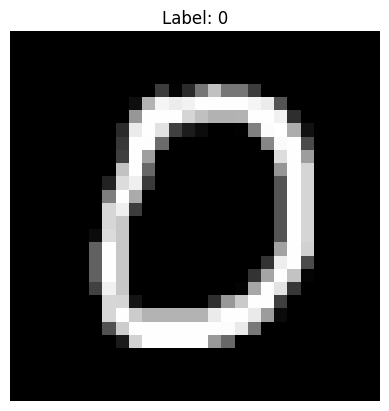

Predicted Label: 0


In [ ]:
#Pytorch - MNIST
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Load the MNIST dataset
transfrom = transforms.ToTensor()

train_data = datasets.MNIST(root='./data', train=True, download=True, transform=transfrom)
test_data = datasets.MNIST(root='./data', train=False, transform=transfrom)

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

#Model
class MNIST_NN(nn.Module):
    def __init__(self):
        super(MNIST_NN, self).__init__()
        self.fc1 = nn.Linear(784, 128)
        self.fc2 = nn.Linear(128,64)
        self.fc3 = nn.Linear(64,10)

    def forward(self, x):
        x = x.view(-1, 784)
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x

model = MNIST_NN()

#Loss & optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.001)

#Training loop
for epoch in range(5):
    for images, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(images)
        loss = loss_fn(outputs, labels)
        loss.backward()
        optimizer.step()
    print(f"Epoch {epoch+1}, Loss: {loss.item()}")

#Accuracy
correct = 0
total = 0
with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        predicted = torch.argmax(outputs, dim=1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f"Test Accuracy: {accuracy:.2f}%")

#Image Recognition
import matplotlib.pyplot as plt

#image
image,label = test_data[10]

#show image
plt.imshow(image.squeeze(), cmap='gray')
plt.title(f"Label: {label}")
plt.axis('off')
plt.show()

#Predict
with torch.no_grad():
    output = model(image.unsqueeze(0))
    predicted_label = torch.argmax(output, dim=1).item()
    print(f"Predicted Label: {predicted_label}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.8601 - loss: 0.4857
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9625 - loss: 0.1244
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9766 - loss: 0.0769
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9829 - loss: 0.0554
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9862 - loss: 0.0436
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9895 - loss: 0.0336
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9920 - loss: 0.0264
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9922 - loss: 0.0234
Epoch 9/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9940 - loss: 0.0178
Epoch 10/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9947 - loss: 0.0162
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9733 - loss: 0.1093
Test Loss: 0.0885, Test Accuracy: 97.72%


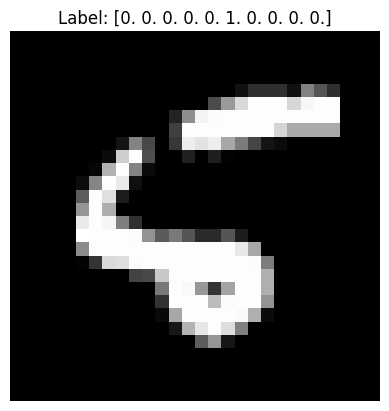

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
Predicted Label: 5


In [ ]:
#MNIST- TNESORLOW
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.utils import to_categorical

# Load the MNIST dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0 #Normlize
y_train = to_categorical(y_train, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)

#Model
model =Sequential  ([
    Flatten(input_shape=(28,28)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

#Compile model

model.compile(
    optimizer = 'adam',
    loss = 'categorical_crossentropy',
    metrics = ['accuracy']
)

#Train
model.fit(x_train, y_train, epochs=10, batch_size=64, verbose=1)

#Evaluate
loss, accuracy = model.evaluate(x_test, y_test)
print(f"Test Loss: {loss:.4f}, Test Accuracy: {accuracy*100:.2f}%")

#image recoginiton
import matplotlib.pyplot as plt

#pick and image
plt.imshow(x_test[8],cmap='gray')
plt.title(f"Label: {y_test[8]}")
plt.axis('off')
plt.show()

#predict
predicted_label = model.predict(x_test[8].reshape(1,28,28))
print(f"Predicted Label: {predicted_label.argmax()}")

In [2]:
# ============================================
# 1. IMPORT LIBRARIES
# ============================================

import os
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import kagglehub

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


# ============================================
# 2. DOWNLOAD DATASET
# ============================================

path = kagglehub.dataset_download("misrakahmed/vegetable-image-dataset")
data_dir = os.path.join(path, "Vegetable Images")

print("Dataset folder:", data_dir)
print("Subfolders:", os.listdir(data_dir))


# ============================================
# 3. TRANSFORMS
# ============================================

transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5],
                         [0.5, 0.5, 0.5])
])


# ============================================
# 4. LOAD DATASETS
# ============================================

train_data = datasets.ImageFolder(
    root=os.path.join(data_dir, "train"),
    transform=transform
)

val_data = datasets.ImageFolder(
    root=os.path.join(data_dir, "validation"),
    transform=transform
)

test_data = datasets.ImageFolder(
    root=os.path.join(data_dir, "test"),
    transform=transform
)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader = DataLoader(val_data, batch_size=32)
test_loader = DataLoader(test_data, batch_size=32)

print("Classes:", train_data.classes)
print("Number of classes:", len(train_data.classes))


# ============================================
# 5. DEFINE CNN MODEL
# ============================================

class CNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 16 * 16, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


model = CNN(num_classes=len(train_data.classes)).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)


# ============================================
# 6. TRAINING LOOP
# ============================================

epochs = 2  # keep small for testing

for epoch in range(epochs):
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    # Validation
    model.eval()
    correct, total = 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    print(f"Epoch {epoch+1}/{epochs} | "
          f"Loss: {running_loss/len(train_loader):.4f} | "
          f"Val Accuracy: {100*correct/total:.2f}%")

print("Training complete.")


# ============================================
# 7. PREDICT DIRECTLY FROM TEST DATASET
# (NO FILE NEEDED)
# ============================================

model.eval()

sample_img, sample_label = test_data[0]
input_tensor = sample_img.unsqueeze(0).to(device)

with torch.no_grad():
    outputs = model(input_tensor)
    probs = torch.softmax(outputs, dim=1)
    confidence, predicted = torch.max(probs, 1)

print("\n=== SAMPLE PREDICTION ===")
print("Actual:", train_data.classes[sample_label])
print("Predicted:", train_data.classes[predicted.item()])
print("Confidence:", f"{confidence.item()*100:.2f}%")

Using device: cpu
Using Colab cache for faster access to the 'vegetable-image-dataset' dataset.
Dataset folder: /kaggle/input/vegetable-image-dataset/Vegetable Images
Subfolders: ['validation', 'test', 'train']
Classes: ['Bean', 'Bitter_Gourd', 'Bottle_Gourd', 'Brinjal', 'Broccoli', 'Cabbage', 'Capsicum', 'Carrot', 'Cauliflower', 'Cucumber', 'Papaya', 'Potato', 'Pumpkin', 'Radish', 'Tomato']
Number of classes: 15
Epoch 1/2 | Loss: 0.9396 | Val Accuracy: 90.67%
Epoch 2/2 | Loss: 0.2429 | Val Accuracy: 95.17%
Training complete.

=== SAMPLE PREDICTION ===
Actual: Bean
Predicted: Bean
Confidence: 97.53%


In [8]:
# ─────────────────────────────────────────
# STEP 1: INSTALL AND IMPORT
# ─────────────────────────────────────────
!pip install datasets -q

import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from datasets import load_dataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import re

# ─────────────────────────────────────────
# STEP 2: LOAD DATASET FROM HUGGINGFACE
# ─────────────────────────────────────────
dataset = load_dataset(
    "NLPC-UOM/Sinhala-English-Code-Mixed-Code-Switched-Dataset",
    data_files="sentence-level-annotation.csv"
)

# Convert to pandas
df = dataset['train'].to_pandas()

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print(df.head(3))

# Check label distribution
print("\nSentiment counts:")
print(df['Sentiment'].value_counts())

print("\nHate Speech counts:")
print(df['Hate_speech'].value_counts())

# ─────────────────────────────────────────
# STEP 3: CLEAN TEXT
# ─────────────────────────────────────────
def preprocess(text):
    text = str(text).lower()
    # remove URLs
    text = re.sub(r'http\S+', '', text)
    # remove hashtags and mentions
    text = re.sub(r'[@#]\w+', '', text)
    # remove special characters (keep sinhala unicode)
    text = re.sub(r'[^\w\s\u0D80-\u0DFF]', '', text)
    # remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean_text'] = df['Sentence'].apply(preprocess)

print("\nBefore:", df['Sentence'][0])
print("After: ", df['clean_text'][0])

# ─────────────────────────────────────────
# STEP 4: ENCODE LABELS
# ─────────────────────────────────────────
# Choose what you want to predict:
# Option A → Sentiment (Positive, Negative, Neutral, Conflict)
# Option B → Hate Speech (Not offensive, Abusive, Hate-Inducing)

TARGET = 'Sentiment'   # change to 'Hate_speech' if you want

# Remove rows with missing labels
df = df.dropna(subset=[TARGET, 'clean_text'])

# Encode labels to numbers
encoder = LabelEncoder()
df['label'] = encoder.fit_transform(df[TARGET])

print("\nClasses:", encoder.classes_)
print("Label mapping:")
for i, cls in enumerate(encoder.classes_):
    print(f"  {i} → {cls}")

num_classes = len(encoder.classes_)

# ─────────────────────────────────────────
# STEP 5: TOKENIZE AND PAD
# ─────────────────────────────────────────
VOCAB_SIZE = 10000
MAX_LEN    = 50    # most sentences are short

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts(df['clean_text'])

print("\nVocab size:", len(tokenizer.word_index))

sequences = tokenizer.texts_to_sequences(df['clean_text'])
padded    = pad_sequences(sequences, maxlen=MAX_LEN, padding='post', truncating='post')

print("Padded shape:", padded.shape)

# ─────────────────────────────────────────
# STEP 6: SPLIT DATA
# ─────────────────────────────────────────
X = padded
y = np.array(df['label'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("\nTrain size:", X_train.shape)
print("Test size: ", X_test.shape)

# ─────────────────────────────────────────
# STEP 7: BUILD LSTM MODEL
# ─────────────────────────────────────────
model = models.Sequential([
    # Word embeddings
    layers.Embedding(VOCAB_SIZE, 64, input_length=MAX_LEN),

    # Bidirectional LSTM
    layers.Bidirectional(layers.LSTM(64, return_sequences=True, dropout=0.2)),
    layers.Bidirectional(layers.LSTM(32, dropout=0.2)),

    # Dense layers
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),

    # Output - softmax for multiclass
    layers.Dense(num_classes, activation='softmax')
])

model.summary()

# ─────────────────────────────────────────
# STEP 8: COMPILE AND TRAIN
# ─────────────────────────────────────────
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_train, y_train,
    epochs=15,
    batch_size=32,
    validation_split=0.2,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=3,
            restore_best_weights=True
        )
    ]
)

# ─────────────────────────────────────────
# STEP 9: EVALUATE
# ─────────────────────────────────────────
loss, acc = model.evaluate(X_test, y_test)
print(f"\nTest Accuracy: {acc*100:.2f}%")

# ─────────────────────────────────────────
# STEP 10: PREDICT YOUR OWN TEXT
# ─────────────────────────────────────────
def predict_text(text, model, tokenizer, encoder):
    clean  = preprocess(text)
    seq    = tokenizer.texts_to_sequences([clean])
    padded = pad_sequences(seq, maxlen=MAX_LEN, padding='post')

    predictions = model.predict(padded, verbose=0)[0]
    predicted   = np.argmax(predictions)
    confidence  = np.max(predictions)

    label = encoder.classes_[predicted]
    print(f"Text:       {text}")
    print(f"Prediction: {label}")
    print(f"Confidence: {confidence*100:.1f}%")
    print()

# Test with your own sentences!
predict_text("Very disappointed about your service",   model, tokenizer, encoder)
predict_text("Thank you so much great service",        model, tokenizer, encoder)
predict_text("data cards sucks",                       model, tokenizer, encoder)
predict_text("Palayan hutto yanna",  model, tokenizer, encoder)

Shape: (13518, 12)
Columns: ['Unnamed: 0', 'Sentence', 'Hate_speech', 'Sentiment', 'Humor', 'Billing or price', 'Customer service', 'Data', 'Network', 'Package', 'Service or product', 'None']
   Unnamed: 0  ... None
0           0  ...    1
1           1  ...    0
2           2  ...    1

[3 rows x 12 columns]

Sentiment counts:
Sentiment
Neutral     8597
Negative    3641
Positive    1156
Conflict     124
Name: count, dtype: int64

Hate Speech counts:
Hate_speech
Not offensive    12262
Abusive            908
Hate-Inducing      348
Name: count, dtype: int64

Before: Ammage Adarayta❤️Eka Dawasak Madi Neda❤️🙏❤️
After:  ammage adaraytaeka dawasak madi neda

Classes: ['Conflict' 'Negative' 'Neutral' 'Positive']
Label mapping:
  0 → Conflict
  1 → Negative
  2 → Neutral
  3 → Positive

Vocab size: 22264
Padded shape: (13518, 50)

Train size: (10814, 50)
Test size:  (2704, 50)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
271/271 ━━━━━━━━━━━━━━━━━━━━ 43s 122ms/step - accuracy: 0.6129 - loss: 0.9593 - val_accuracy: 0.7369 - val_loss: 0.7320
Epoch 2/15
271/271 ━━━━━━━━━━━━━━━━━━━━ 33s 123ms/step - accuracy: 0.7688 - loss: 0.6590 - val_accuracy: 0.7406 - val_loss: 0.7061
Epoch 3/15
271/271 ━━━━━━━━━━━━━━━━━━━━ 36s 134ms/step - accuracy: 0.8360 - loss: 0.4811 - val_accuracy: 0.7573 - val_loss: 0.6933
Epoch 4/15
271/271 ━━━━━━━━━━━━━━━━━━━━ 32s 119ms/step - accuracy: 0.8911 - loss: 0.3218 - val_accuracy: 0.7402 - val_loss: 0.7601
Epoch 5/15
271/271 ━━━━━━━━━━━━━━━━━━━━ 42s 124ms/step - accuracy: 0.9283 - loss: 0.2274 - val_accuracy: 0.7305 - val_loss: 0.8290
Epoch 6/15
271/271 ━━━━━━━━━━━━━━━━━━━━ 35s 129ms/step - accuracy: 0.9437 - loss: 0.1791 - val_accuracy: 0.7351 - val_loss: 0.9652
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.7383 - loss: 0.7100

Test Accuracy: 74.41%
Text:       Very disappointed about your service
Prediction: Negative
Confidence: 95.1%

Text:       Thank you so muc

In [ ]:
# ─────────────────────────────────────────
# STEP 1: INSTALL AND IMPORT
# ─────────────────────────────────────────
# !pip install datasets -q    # (uncomment if running in fresh env)

import numpy as np
import re
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from datasets import load_dataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.preprocessing.text import Tokenizer       # still using keras tokenizer for simplicity
from tensorflow.keras.preprocessing.sequence import pad_sequences

# For reproducibility
torch.manual_seed(42)
np.random.seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ─────────────────────────────────────────
# STEP 2: LOAD DATASET
# ─────────────────────────────────────────
dataset = load_dataset(
    "NLPC-UOM/Sinhala-English-Code-Mixed-Code-Switched-Dataset",
    data_files="sentence-level-annotation.csv"
)

df = dataset['train'].to_pandas()

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print(df.head(3))

print("\nSentiment counts:")
print(df['Sentiment'].value_counts())

# ─────────────────────────────────────────
# STEP 3: CLEAN TEXT (same as before)
# ─────────────────────────────────────────
def preprocess(text):
    text = str(text).lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'[@#]\w+', '', text)
    text = re.sub(r'[^\w\s\u0D80-\u0DFF]', '', text)   # keep Sinhala
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean_text'] = df['Sentence'].apply(preprocess)

print("\nBefore:", df['Sentence'][0])
print("After: ", df['clean_text'][0])

# ─────────────────────────────────────────
# STEP 4: ENCODE LABELS
# ─────────────────────────────────────────
TARGET = 'Sentiment'          # or 'Hate_speech'

df = df.dropna(subset=[TARGET, 'clean_text'])

encoder = LabelEncoder()
df['label'] = encoder.fit_transform(df[TARGET])

print("\nClasses:", encoder.classes_)
print("Label mapping:")
for i, cls in enumerate(encoder.classes_):
    print(f"  {i} → {cls}")

num_classes = len(encoder.classes_)

# ─────────────────────────────────────────
# STEP 5: TOKENIZE & PAD (still using Keras Tokenizer for consistency)
# ─────────────────────────────────────────
VOCAB_SIZE = 10000
MAX_LEN    = 50

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts(df['clean_text'])

print("\nVocab size:", len(tokenizer.word_index))

sequences = tokenizer.texts_to_sequences(df['clean_text'])
padded    = pad_sequences(sequences, maxlen=MAX_LEN, padding='post', truncating='post')

print("Padded shape:", padded.shape)

# ─────────────────────────────────────────
# STEP 6: SPLIT DATA
# ─────────────────────────────────────────
X = padded
y = df['label'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("\nTrain size:", X_train.shape)
print("Test size: ", X_test.shape)

# ─────────────────────────────────────────
# PyTorch Dataset
# ─────────────────────────────────────────
class TextDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.LongTensor(X)
        self.y = torch.LongTensor(y)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_ds = TextDataset(X_train, y_train)
test_ds  = TextDataset(X_test,  y_test)

BATCH_SIZE = 32

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

# ─────────────────────────────────────────
# STEP 7: DEFINE LSTM MODEL
# ─────────────────────────────────────────
class SentimentLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes, num_lstm_layers=2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)

        self.lstm = nn.LSTM(
            embed_dim,
            hidden_dim,
            num_layers=num_lstm_layers,
            batch_first=True,
            bidirectional=True,
            dropout=0.2 if num_lstm_layers > 1 else 0
        )

        # After bidirectional → hidden_dim * 2
        self.fc1 = nn.Linear(hidden_dim * 2, 64)
        self.dropout = nn.Dropout(0.3)
        self.fc2 = nn.Linear(64, num_classes)

    def forward(self, x):
        embeds = self.embedding(x)              # (batch, seq_len, embed_dim)

        lstm_out, (hn, cn) = self.lstm(embeds) # hn: (num_layers*2, batch, hidden)

        # Take the last hidden state (bidirectional → concat forward & backward)
        hidden = torch.cat((hn[-2,:,:], hn[-1,:,:]), dim=1)   # (batch, hidden*2)

        out = torch.relu(self.fc1(hidden))
        out = self.dropout(out)
        out = self.fc2(out)
        return out

# Initialize model
EMBED_DIM  = 64
HIDDEN_DIM = 64

model = SentimentLSTM(
    vocab_size=VOCAB_SIZE,
    embed_dim=EMBED_DIM,
    hidden_dim=HIDDEN_DIM,
    num_classes=num_classes,
    num_lstm_layers=2
).to(device)

print(model)

# ─────────────────────────────────────────
# STEP 8: TRAINING SETUP
# ─────────────────────────────────────────
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct += (preds == y_batch).sum().item()
        total += y_batch.size(0)

    return total_loss / len(loader), correct / total

def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)

            total_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct += (preds == y_batch).sum().item()
            total += y_batch.size(0)

    return total_loss / len(loader), correct / total

# ─────────────────────────────────────────
# STEP 9: TRAIN
# ─────────────────────────────────────────
EPOCHS = 15
best_val_acc = 0

for epoch in range(EPOCHS):
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion, device)

    # Simple early stopping using validation split from train
    # (you can also create a separate val_loader if you want)
    val_loss, val_acc = evaluate(model, test_loader, criterion, device)  # using test as proxy here

    print(f"Epoch {epoch+1:2d}/{EPOCHS} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_model.pt")
        print("  → Saved better model")

# Load best model for final evaluation
model.load_state_dict(torch.load("best_model.pt"))
_, test_acc = evaluate(model, test_loader, criterion, device)
print(f"\nFinal Test Accuracy: {test_acc*100:.2f}%")

# ─────────────────────────────────────────
# STEP 10: PREDICT FUNCTION
# ─────────────────────────────────────────
def predict_text(text, model, tokenizer, encoder, max_len=50, device="cpu"):
    model.eval()
    clean = preprocess(text)
    seq = tokenizer.texts_to_sequences([clean])
    padded = pad_sequences(seq, maxlen=max_len, padding='post', truncating='post')

    tensor = torch.LongTensor(padded).to(device)

    with torch.no_grad():
        pred = model(tensor)
        probs = torch.softmax(pred, dim=1)[0]
        predicted = torch.argmax(probs).item()
        confidence = probs[predicted].item()

    label = encoder.classes_[predicted]
    print(f"Text:       {text}")
    print(f"Prediction: {label}")
    print(f"Confidence: {confidence*100:.1f}%\n")

# ─────────────────────────────────────────
# Try some examples
# ─────────────────────────────────────────
model.load_state_dict(torch.load("best_model.pt"))
model.to(device)

predict_text("Very disappointed about your service",   model, tokenizer, encoder, device=device)
predict_text("Thank you so much great service",        model, tokenizer, encoder, device=device)
predict_text("data cards sucks",                       model, tokenizer, encoder, device=device)
predict_text("Palayan hutto yanna",                    model, tokenizer, encoder, device=device)